# Case Study 1 – Trends in Euro Area Banking Metrics, 2019–2023

How did asset quality, capitalisation and profitability of euro area banks evolve between 2019
and 2023, across countries and macro-regions?

The notebook starts from a BankFocus export of bank-level financial statements, cleans it into
one statement per bank and year, aggregates it to country, macro-region and euro area level, and
draws the charts of the case study.

**Indicators**
- *Asset quality*: NPL ratio = non-performing loans / net loans to customers
- *Capitalisation*: Total capital, Tier 1, CET1 and Tier 2 as % of risk-weighted assets
- *Profitability*: ROE, ROA, net interest income and net interest margin (NIM)

Ratios are **volume-weighted**: sum(numerator) / sum(denominator) over the same banks. `EA` is
the euro area computed in the same way.

## Setup

In [1]:
suppressPackageStartupMessages({
  library(readxl)     # read the sheets of the BankFocus export
  library(dplyr)      # data manipulation (filter, mutate, joins, summarise)
  library(tidyr)      # pivot_longer / pivot_wider
  library(purrr)      # map / reduce over sheets, years and indicators
  library(ggplot2)    # ROE distribution charts
})

# Size of the charts shown in the notebook
options(repr.plot.width = 14, repr.plot.height = 7.5, repr.plot.res = 110)

In [2]:
DATA_FILE <- "data/Export 2019 2023.xlsx"   # BankFocus export (not included: licensed data)
# The BankFocus export is licensed data and is not part of the repository
if (!file.exists(DATA_FILE)) {
  stop("BankFocus export not found at '", DATA_FILE, "'. The data are licensed and not ",
       "included in the repository; the executed notebook cs1_banking_metrics.ipynb shows ",
       "all the results.", call. = FALSE)
}
OUT_DIR   <- "output"   # tables written at the end of the notebook
YEARS     <- 2019:2023
# Sheet of the export with the balance sheet of each year, named by year
YEARLY_SHEETS <- setNames(c("Results", "Results (20)", "Results (21)",
                            "Results (22)", "Results (23)"), YEARS)

# One statement per bank and year, chosen by this consolidation-code priority:
#   C1 consolidated, no unconsolidated companion  U1 unconsolidated, no consolidated companion
#   U2 unconsolidated, with a consolidated companion  C2 consolidated, with an unconsolidated one
#   C* / U* additional statements (e.g. a second accounting standard)
# NF (no financials) and LF (limited financials) are not in the list and are dropped.
CODE_PRIORITY <- c("C1", "U1", "U2", "C2", "C*", "U*")
# Croatia adopted the euro only in 2023
EXCLUDED_COUNTRIES <- c("HR")
# National central banks are in the BankFocus bank list but are not part of the banking sector
CENTRAL_BANKS <- c(
  "DEUTSCHE BUNDESBANK", "BANQUE DE FRANCE", "BANCA D'ITALIA", "BANCO DE ESPANA",
  "BANQUE CENTRALE DU LUXEMBOURG", "BANK OF GREECE", "BANCO DE PORTUGAL, EP",
  "CENTRAL BANK & FINANCIAL SERVICES AUTHORITY OF IRELAND",
  "SUOMEN PANKKI FINLANDS BANK", "NARODNA BANKA SLOVENSKA", "CENTRAL BANK OF CYPRUS",
  "LATVIJAS BANKA", "CENTRAL BANK OF MALTA", "NEDERLANDSCHE BANK NV (DE)"
)
# Macro-regions used in the presentation (country ISO codes)
REGIONS <- list(
  North  = c("EE", "FI", "IE", "NL"),
  Center = c("AT", "BE", "DE", "FR", "LU"),
  South  = c("CY", "ES", "GR", "IT", "MT", "PT"),
  East   = c("LT", "LV", "SI", "SK")
)
# Identifier columns of every sheet: bank name, country (ISO code), consolidation code
ID_COLS <- c("name", "country", "code")
# Statistical confidentiality: no published value may rest on fewer than 3 banks, otherwise a
# "country" figure would reveal the figures of an individual bank
MIN_BANKS <- 3

## 1. Loading the data

The export has one sheet per year for the balance sheet (`Results` … `Results (23)`), one sheet
with net income, equity, net interest income and total assets for all years side by side
(`Results (2)`) and one with the net interest margin (`Results (3)`). Every sheet becomes a long
table with one row per statement and year.

Each sheet lists the banks **in a different order**, so sheets are always processed separately
and never combined by row position.

In [3]:
# read_sheet(sheet)
# Reads one sheet of the export ("n.a." becomes NA), drops the BankFocus row number and
# names the first three columns name, country and code. The other columns keep the long
# BankFocus names and are renamed by the loaders below.
read_sheet <- function(sheet) {
  df <- read_excel(DATA_FILE, sheet = sheet, na = "n.a.", .name_repair = "unique_quiet")
  df <- df[, -1]  # column 1 is only the row number of the export
  names(df)[1:3] <- ID_COLS
  df
}

# load_balance_sheet()
# Balance-sheet items from the five yearly sheets, stacked into one table with one row per
# statement and year. Each sheet is renamed on its own, so the different order of the banks
# in each sheet does not matter. Amounts in EUR thousands.
load_balance_sheet <- function() {
  vars <- c("total_assets", "net_loans", "npl", "total_capital", "tier1", "cet1",
            "tier2", "rwa")
  imap_dfr(YEARLY_SHEETS, function(sheet, year) {
    df <- read_sheet(sheet)[, 1:(3 + length(vars))]  # drops an empty trailing column in 2022
    names(df) <- c(ID_COLS, vars)
    mutate(df, year = as.integer(year))
  })
}

# load_profitability()
# "Results (2)" has all years side by side: after the 3 id columns come net income, equity and
# net interest income for 2019, then the same three for 2020, and so on (columns 4-18), then
# total assets for 2019-2023 (columns 19-23). For year i the columns are picked by position
# and one table per year is built; the five tables are stacked.
load_profitability <- function() {
  df <- read_sheet("Results (2)")
  map_dfr(seq_along(YEARS), function(i) {
    tibble(df[, ID_COLS],
           net_income   = df[[3 + 3 * (i - 1) + 1]],
           equity       = df[[3 + 3 * (i - 1) + 2]],
           nii          = df[[3 + 3 * (i - 1) + 3]],
           total_assets = df[[18 + i]],   # columns 19-23
           year         = YEARS[i])
  })
}

# load_nim()
# Net interest margin (%), one column per year (columns 4-8): turned into a long table, with
# the year read from the last four characters of the column name.
load_nim <- function() {
  read_sheet("Results (3)") %>%
    pivot_longer(cols = 4:8, names_to = "col", values_to = "nim") %>%
    mutate(year = as.integer(substr(col, nchar(col) - 3, nchar(col)))) %>%
    select(-col)
}

bs_raw   <- load_balance_sheet()   # total assets, loans, NPL, capital, RWAs
prof_raw <- load_profitability()   # net income, equity, NII, total assets
nim_raw  <- load_nim()             # net interest margin
# Number of statements per year and consolidation codes in 2019
cat("Statements per year:", nrow(bs_raw) / length(YEARS), "\n")
count(filter(bs_raw, year == 2019), code, sort = TRUE)

Statements per year: 5552 


code,n
<chr>,<int>
U1,2860
C2,668
U2,668
NF,608
U*,408
C*,247
C1,92
LF,1


## 2. Cleaning

1. Keep euro area banks only (no Croatia), drop national central banks and statements without
   financials (codes NF and LF).
2. Keep **one statement per bank and year** (bank = name + country): among the statements that
   report the variables needed for an indicator, the one with the highest-priority consolidation
   code. Summing all statements would count the same bank twice.
3. Use a **balanced sample** for balance-sheet indicators (loans, NPL, capital): only banks that
   report them in all five years. The number of banks reporting NPL changes a lot from year to
   year (see the table below), and an unbalanced sample would mix changes in the ratios with
   changes in which banks are observed. Profitability data are reported consistently and use
   all banks.
4. **Statistical confidentiality**: a country value based on fewer than 3 banks is not shown,
   because it would reveal the figures of an individual bank. Only aggregates are displayed in
   this notebook.

In [4]:
apply_sample_filters <- function(df) {
  df %>% filter(!country %in% EXCLUDED_COUNTRIES,
                !name %in% CENTRAL_BANKS,
                code %in% CODE_PRIORITY)
}

one_statement_per_bank <- function(df, required) {
  df %>%
    filter(if_all(all_of(required), ~ !is.na(.x))) %>%
    mutate(rank = match(code, CODE_PRIORITY)) %>%
    arrange(rank) %>%
    distinct(name, country, year, .keep_all = TRUE) %>%
    select(-rank)
}

balanced_sample <- function(df) {
  df %>% group_by(name, country) %>% filter(n_distinct(year) == length(YEARS)) %>% ungroup()
}

# add_region(df): adds the macro-region of each bank's country
add_region <- function(df) {
  # Named vector country -> region, e.g. c(EE = "North", FI = "North", ..., SK = "East")
  lookup <- setNames(rep(names(REGIONS), lengths(REGIONS)), unlist(REGIONS))
  mutate(df, region = unname(lookup[country]))
}

# Sample filters on the three tables
bs   <- apply_sample_filters(bs_raw)
prof <- apply_sample_filters(prof_raw)
nim  <- apply_sample_filters(nim_raw)

# Banks reporting each indicator, by year: NPL coverage collapses in 2021 (mainly Germany)
reporting <- function(df, vars) count(one_statement_per_bank(df, vars), year, name = "banks")
list(npl = reporting(bs, c("net_loans", "npl")),
     capital = reporting(bs, c("total_capital", "tier1", "cet1", "tier2", "rwa")),
     roe = reporting(prof, c("net_income", "equity"))) %>%
  imap(~ rename(.x, !!.y := banks)) %>%
  reduce(full_join, by = "year")

year,npl,capital,roe
<int>,<int>,<int>,<int>
2019,2373,1642,3357
2020,2337,1600,3328
2021,1268,1686,3324
2022,1332,1595,3286
2023,1335,1569,3193


In [5]:
# Banks in the balanced samples (observed in all five years)
c(npl = n_distinct(select(balanced_sample(one_statement_per_bank(bs, c("net_loans", "npl"))),
                          name, country)),
  capital = n_distinct(select(balanced_sample(one_statement_per_bank(
    bs, c("total_capital", "tier1", "cet1", "tier2", "rwa"))), name, country)))

npl capital 
   1144    1169

In [6]:
# Central banks found in the export and removed
bs_raw %>%
  filter(name %in% CENTRAL_BANKS) %>%
  distinct(name, country) %>%
  arrange(country)

name,country
<chr>,<chr>
CENTRAL BANK OF CYPRUS,CY
DEUTSCHE BUNDESBANK,DE
BANCO DE ESPANA,ES
SUOMEN PANKKI FINLANDS BANK,FI
BANQUE DE FRANCE,FR
BANK OF GREECE,GR
CENTRAL BANK & FINANCIAL SERVICES AUTHORITY OF IRELAND,IE
BANCA D'ITALIA,IT
BANQUE CENTRALE DU LUXEMBOURG,LU


## 3. Aggregation by country, euro area and macro-region

In [7]:
# with_euro_area(df, f)
# Applies the summary function f (built with ratio(), total() or median_of() below) to each
# country and year, and to the whole euro area ("EA") in each year. Returns a long table
# (year, country, value). Country values based on fewer than MIN_BANKS banks are suppressed
# (set to NA); the euro area value always rests on many banks.
with_euro_area <- function(df, f) {
  bind_rows(
    # countries: pick(everything()) passes the rows of the group to f
    df %>% group_by(year, country) %>%
      summarise(value = f(pick(everything())), n_banks = n(), .groups = "drop") %>%
      mutate(value = if_else(n_banks < MIN_BANKS, NA_real_, value)) %>%
      select(-n_banks),
    # euro area: all banks of the year together
    df %>% group_by(year) %>% summarise(value = f(pick(everything())), .groups = "drop") %>%
      mutate(country = "EA")
  )
}
# Summary functions: each returns a function of the rows of one group
# volume-weighted ratio, e.g. ratio("npl", "net_loans") = total NPL / total net loans
ratio     <- function(num, den) function(d) sum(d[[num]]) / sum(d[[den]])
total     <- function(col) function(d) sum(d[[col]]) / 1e6   # EUR thousands -> EUR bn
median_of <- function(col) function(d) median(d[[col]])

# country_metrics(bs, prof, nim)
# All country and euro area indicators in one wide table (one row per year and country).
# Each indicator has its own sample: the banks that report the variables it needs (balanced
# over the five years for loans, NPL and capital), so a missing value for one indicator does
# not remove the bank from the others.
country_metrics <- function(bs, prof, nim) {
  npl <- balanced_sample(one_statement_per_bank(bs, c("net_loans", "npl")))
  cap <- balanced_sample(one_statement_per_bank(bs, c("total_capital", "tier1", "cet1", "tier2", "rwa")))
  roe <- one_statement_per_bank(prof, c("net_income", "equity"))
  roa <- one_statement_per_bank(prof, c("net_income", "total_assets"))
  nii <- one_statement_per_bank(prof, "nii")
  nim <- one_statement_per_bank(nim, "nim")
  list(
    net_loans_bn        = with_euro_area(npl, total("net_loans")),
    npl_bn              = with_euro_area(npl, total("npl")),
    npl_ratio           = with_euro_area(npl, ratio("npl", "net_loans")),
    total_capital_ratio = with_euro_area(cap, ratio("total_capital", "rwa")),
    tier1_ratio         = with_euro_area(cap, ratio("tier1", "rwa")),
    cet1_ratio          = with_euro_area(cap, ratio("cet1", "rwa")),
    tier2_ratio         = with_euro_area(cap, ratio("tier2", "rwa")),
    roe                 = with_euro_area(roe, ratio("net_income", "equity")),
    roa                 = with_euro_area(roa, ratio("net_income", "total_assets")),
    nii_bn              = with_euro_area(nii, total("nii")),
    # NIM is already a ratio for each bank, so it is summarised with the median
    nim_median          = with_euro_area(nim, median_of("nim"))
  ) %>%
    imap(~ rename(.x, !!.y := value)) %>%                # value -> name of the indicator
    reduce(full_join, by = c("year", "country")) %>%     # one column per indicator
    arrange(year, country)
}

# region_metrics(bs, prof)
# Indicators by macro-region and year: aggregate NPL ratio and total capital ratio
# (volume-weighted, balanced samples), and the distribution of ROE across banks (25th
# percentile, median, 75th percentile), which shows how different banks in the region are.
region_metrics <- function(bs, prof) {
  npl <- add_region(balanced_sample(one_statement_per_bank(bs, c("net_loans", "npl"))))
  cap <- add_region(balanced_sample(one_statement_per_bank(
    bs, c("total_capital", "tier1", "cet1", "tier2", "rwa"))))
  # Bank-level ROE distribution; banks with zero or negative equity are left out
  roe <- add_region(one_statement_per_bank(prof, c("net_income", "equity"))) %>%
    filter(equity > 0) %>%
    mutate(bank_roe = net_income / equity)
  list(
    npl %>% group_by(year, region) %>%
      summarise(npl_ratio = sum(npl) / sum(net_loans), .groups = "drop"),
    cap %>% group_by(year, region) %>%
      summarise(total_capital_ratio = sum(total_capital) / sum(rwa), .groups = "drop"),
    roe %>% group_by(year, region) %>%
      summarise(roe_p25 = quantile(bank_roe, 0.25), roe_median = median(bank_roe),
                roe_p75 = quantile(bank_roe, 0.75), n_banks_roe = n(), .groups = "drop")
  ) %>%
    reduce(full_join, by = c("year", "region")) %>%
    arrange(year, region)
}

countries <- country_metrics(bs, prof, nim)
regions   <- region_metrics(bs, prof)

In [8]:
# Euro area, % (NIM already in %)
countries %>%
  filter(country == "EA") %>%
  transmute(year,
            npl_ratio = 100 * npl_ratio, total_capital = 100 * total_capital_ratio,
            cet1 = 100 * cet1_ratio, roe = 100 * roe, roa = 100 * roa, nim_median) %>%
  mutate(across(-year, ~ round(.x, 2)))

year,npl_ratio,total_capital,cet1,roe,roa,nim_median
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2019,3.60,18.39,15.11,5.50,0.41,1.55
2020,3.33,19.33,15.95,2.89,0.21,1.45
2021,2.75,19.34,15.93,6.66,0.46,1.35
2022,2.46,19.10,15.68,6.57,0.46,1.44
2023,2.52,19.61,16.23,8.96,0.67,2.01


In [9]:
# Macro-regions, %
regions %>%
  mutate(across(c(npl_ratio, total_capital_ratio, roe_p25, roe_median, roe_p75),
                ~ round(100 * .x, 2)))

year,region,npl_ratio,total_capital_ratio,roe_p25,roe_median,roe_p75,n_banks_roe
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2019,Center,2.48,18.32,1.17,2.37,5.29,2371
2019,East,3.63,17.20,3.51,8.17,11.95,46
2019,North,2.41,20.67,2.65,3.69,6.43,233
2019,South,7.32,17.33,1.83,4.08,7.24,696
2020,Center,2.45,19.31,0.92,1.90,4.24,2368
2020,East,3.34,17.66,1.62,5.27,8.20,47
2020,North,2.70,21.22,1.24,3.01,4.49,222
2020,South,5.91,18.41,0.87,3.26,5.40,682
2021,Center,2.24,19.24,1.05,2.29,5.69,2358


## 4. Charts

Same charts as in the presentation. Colours: 2019 teal, 2020 yellow, 2021 light blue,
2022 pink, 2023 navy. The y axis always ends on a round value above the highest bar.

In [10]:
# Colours of the years, as in the presentation: 2019 teal, 2020 yellow, 2021 light blue,
# 2022 pink, 2023 navy
YEAR_COLOURS <- c(palette.colors(n = 1, "Set3"), "yellow", palette.colors(1, palette = "Paired"),
                  palette.colors(1, palette = "Pastel1"), "#000080")
REGION_NAMES <- c(North = "Northern", South = "Southern", Center = "Central", East = "Eastern")

# y-axis limits on "pretty" round values that include every bar
nice_ylim <- function(...) range(pretty(c(0, na.omit(unlist(list(...))))))

# year_matrix(...)
# Matrix for barplot(beside = TRUE): rows = years, columns = countries in alphabetical
# order with the euro area last. scale = 100 turns ratios into %; include_ea = FALSE leaves
# out the euro area (for volumes, where it would dwarf the countries).
year_matrix <- function(column, scale = 100, include_ea = TRUE) {
  wide <- countries %>%
    select(year, country, value = all_of(column)) %>%
    pivot_wider(names_from = country, values_from = value) %>%
    arrange(year)
  order <- c(sort(setdiff(names(wide)[-1], "EA")), if (include_ea) "EA")
  m <- as.matrix(wide[, order]) * scale
  rownames(m) <- wide$year
  m
}

# year_bars(...): grouped bars, one group per country and one bar per year, with a subtitle
# and the legend of the years
year_bars <- function(m, title, subtitle) {
  barplot(m, beside = TRUE, col = YEAR_COLOURS, border = "grey", main = title, ylim = nice_ylim(m))
  mtext(subtitle, side = 3, line = 0.4, cex = 0.9)
  legend("topright", legend = rownames(m), cex = 0.9, fill = YEAR_COLOURS, border = "white",
         bty = "n")
}

# region_roe_chart(...): median bank ROE of a region by year (point) with the interquartile
# range (bar from the 25th to the 75th percentile)
region_roe_chart <- function(region) {
  d <- filter(regions, region == !!region)
  ggplot(d, aes(x = year, y = roe_median)) +
    geom_errorbar(aes(ymin = roe_p25, ymax = roe_p75), linewidth = 3, width = 0.2) +
    geom_point(colour = "#800080", size = 5) +
    xlab("Year") + ylab("ROE") +
    ggtitle(paste0("Distribution of Return on Equity in the ", REGION_NAMES[[region]],
                   " Euro Area \nInterquantile Range of ROE by year")) +
    theme_bw(base_size = 15)
}

# region_npl_capital_chart(...): NPL ratio and total capital ratio of a region by year, one
# chart above the other (par(mfrow = c(2, 1)))
region_npl_capital_chart <- function(region) {
  d <- filter(regions, region == !!region)
  name <- REGION_NAMES[[region]]
  old <- par(mfrow = c(2, 1))
  on.exit(par(old))
  barplot(setNames(d$npl_ratio, d$year), col = "#000080", xlab = "Year",
          main = paste("NPL Ratio", name, "Euro Area"), ylim = nice_ylim(d$npl_ratio))
  barplot(setNames(d$total_capital_ratio, d$year), col = "#5F0000", xlab = "Year",
          main = paste("Total Capital Ratio", name, "Euro Area"),
          ylim = nice_ylim(d$total_capital_ratio))
}

### Asset quality

**Volumes of loans and NPL.** Total loans (pink) with performing loans (teal) drawn on top: the
pink part at the top of each bar is the volume of non-performing loans.

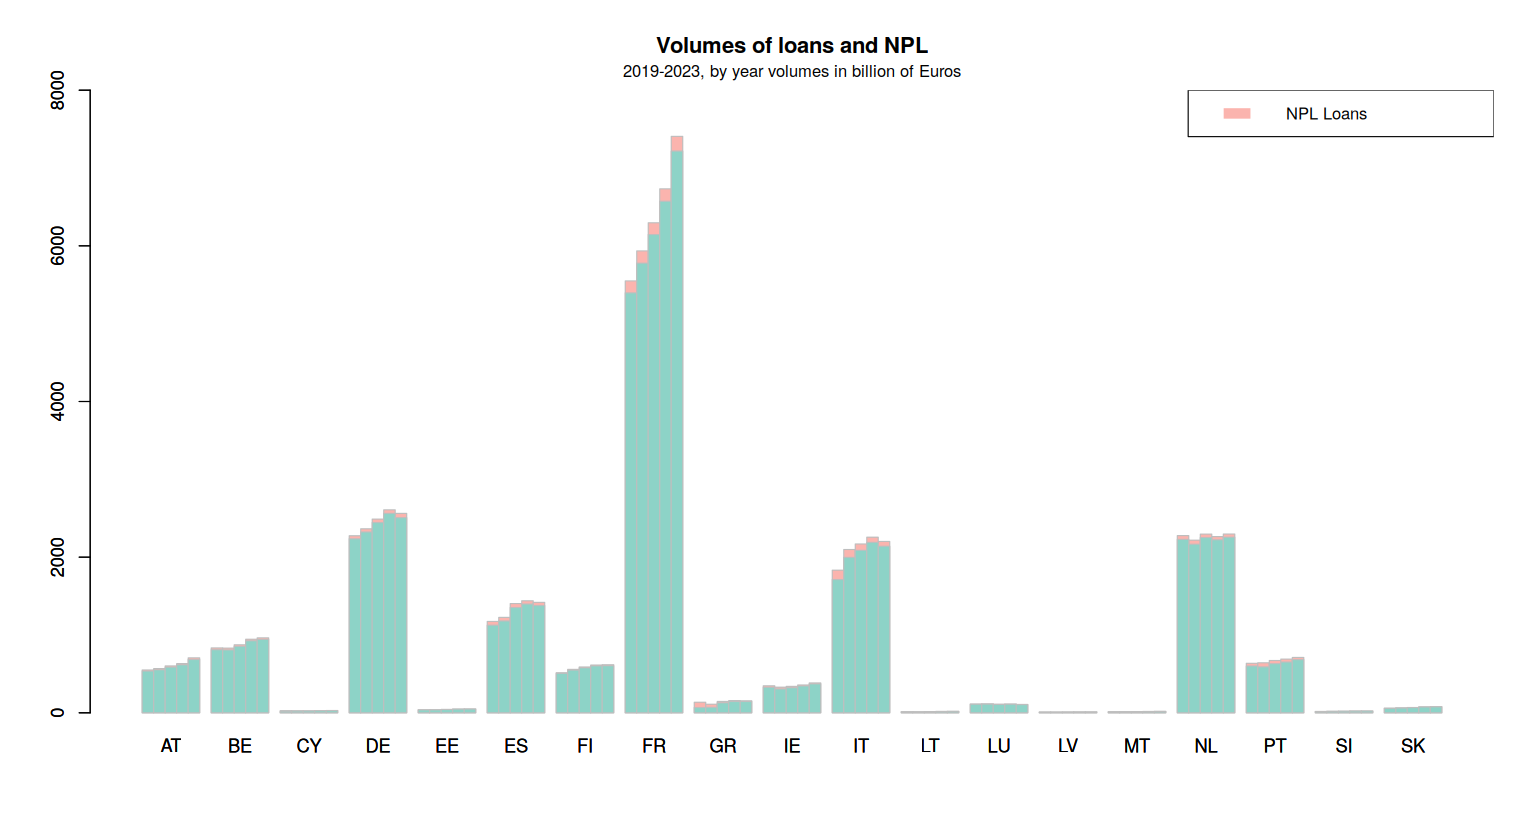

In [11]:
# Volumes in EUR bn by country (euro area left out: it would dwarf the countries)
total <- year_matrix("net_loans_bn", scale = 1, include_ea = FALSE)
npl   <- year_matrix("npl_bn", scale = 1, include_ea = FALSE)
# First all loans in pink, then performing loans (total - NPL) in teal on top
barplot(total, beside = TRUE, col = palette.colors(n = 1, "Pastel1"), border = "grey",
        main = "Volumes of loans and NPL", ylim = nice_ylim(total))
barplot(total - npl, beside = TRUE, col = palette.colors(n = 1, "Set3"), add = TRUE,
        border = "grey", ylim = nice_ylim(total))
mtext("2019-2023, by year volumes in billion of Euros", side = 3, line = 0.4, cex = 0.9)
legend("topright", legend = "NPL Loans", cex = 0.9,
       fill = palette.colors(1, palette = "Pastel1"), border = "white")

**NPL ratio.**

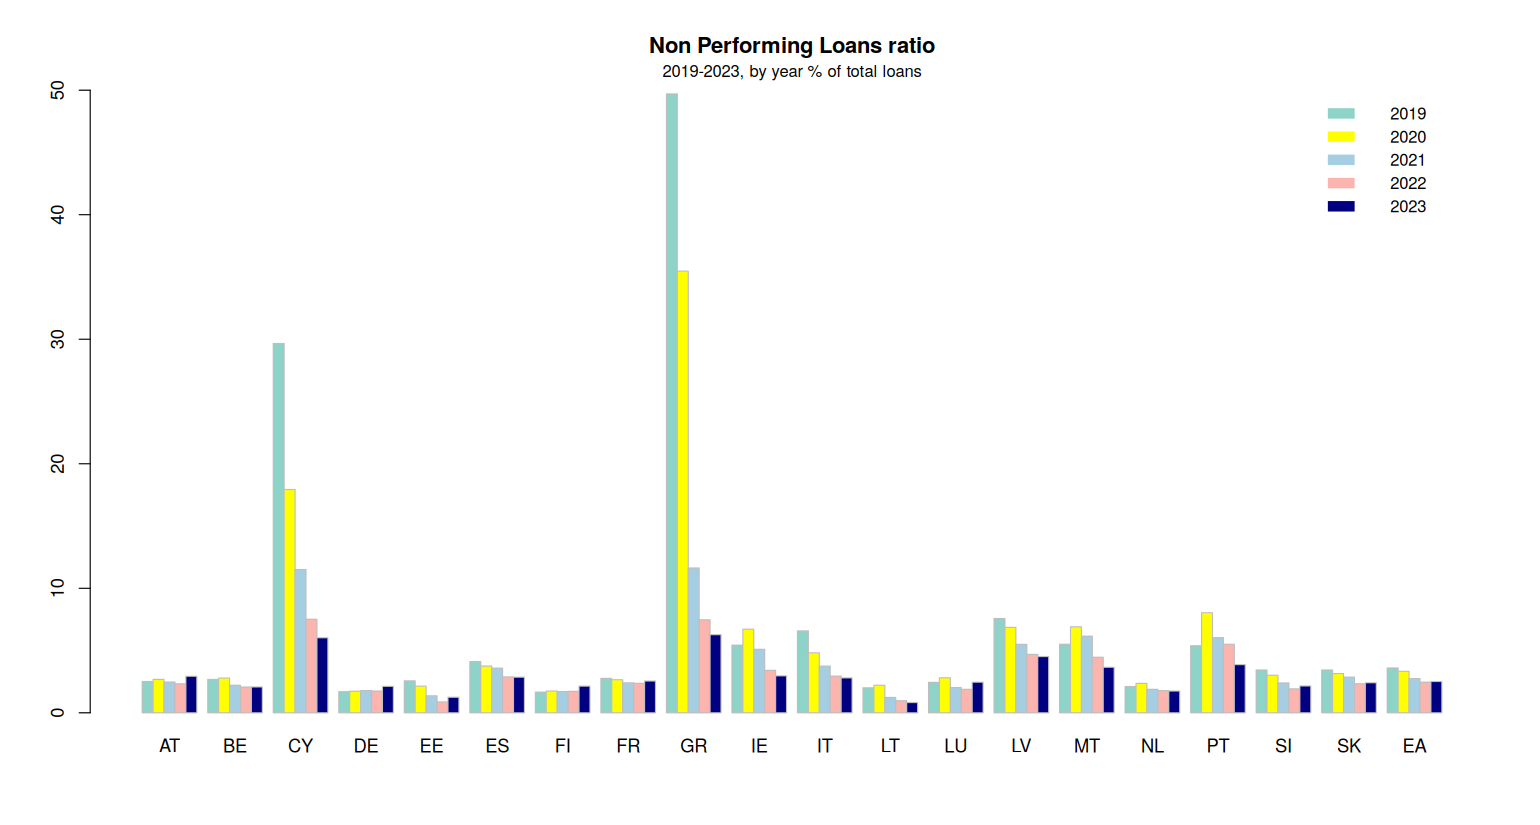

In [12]:
year_bars(year_matrix("npl_ratio"), "Non Performing Loans ratio",
          "2019-2023, by year % of total loans")

### Capitalisation

Total capital, Tier 1, CET1 and Tier 2 as % of risk-weighted assets, drawn on top of each other:
five bars (2019–2023) per country.

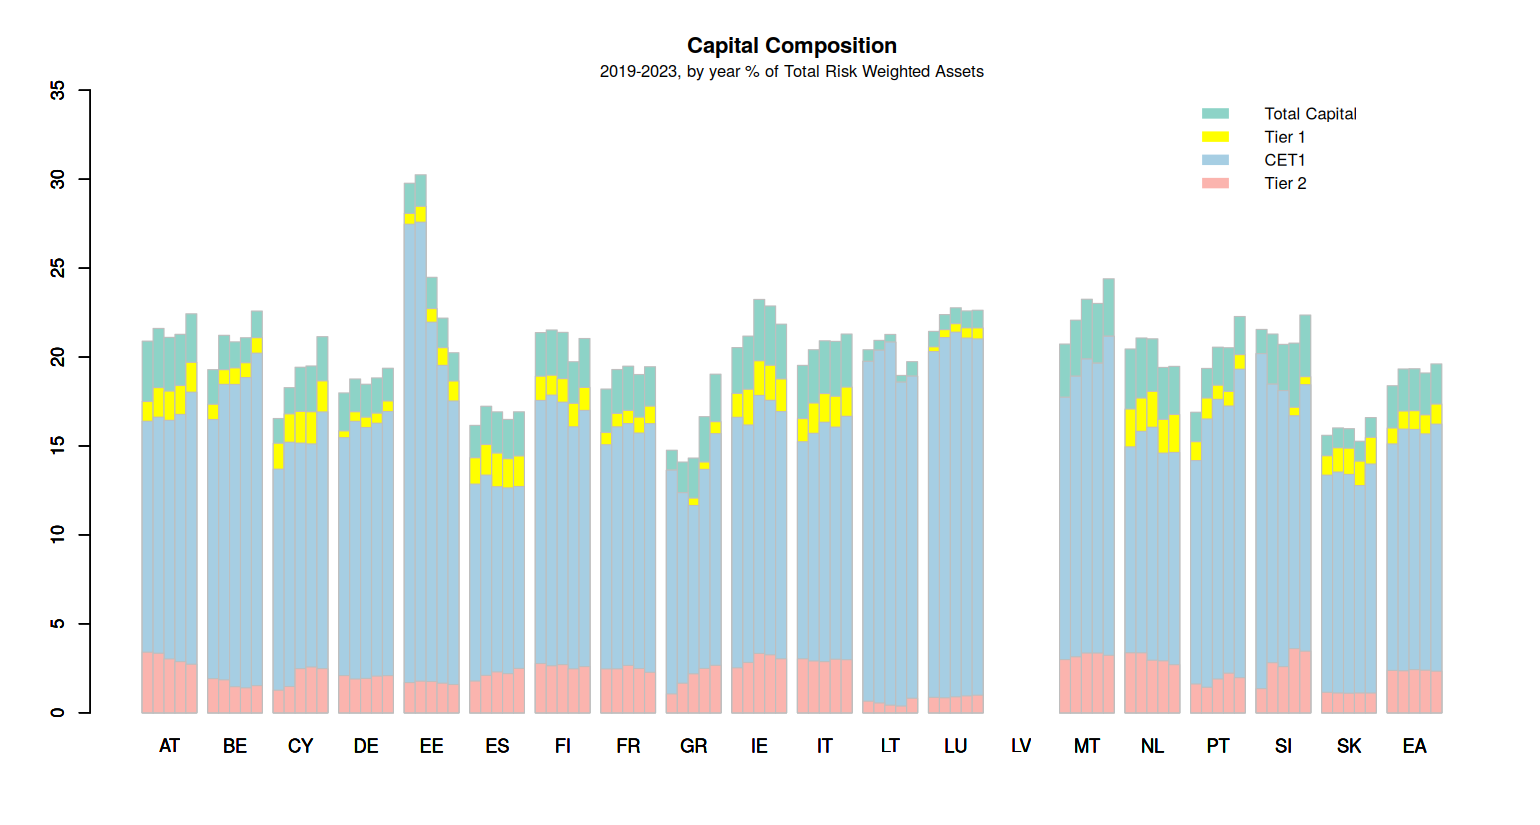

In [13]:
# Four layers drawn on top of each other (add = TRUE), tallest first, on a common y axis
layers  <- c(total_capital_ratio = "Total Capital", tier1_ratio = "Tier 1",
             cet1_ratio = "CET1", tier2_ratio = "Tier 2")
colours <- c(palette.colors(n = 1, "Set3"), "yellow", palette.colors(1, palette = "Paired"),
             palette.colors(1, palette = "Pastel1"))
ylim <- nice_ylim(map(names(layers), year_matrix))
for (i in seq_along(layers)) {
  barplot(year_matrix(names(layers)[i]), beside = TRUE, col = colours[i], border = "grey",
          add = i > 1, ylim = ylim, main = if (i == 1) "Capital Composition" else NULL)
}
mtext("2019-2023, by year % of Total Risk Weighted Assets", side = 3, line = 0.4, cex = 0.9)
legend("topright", legend = layers, cex = 0.9, fill = colours, border = "white", bty = "n")

### Profitability

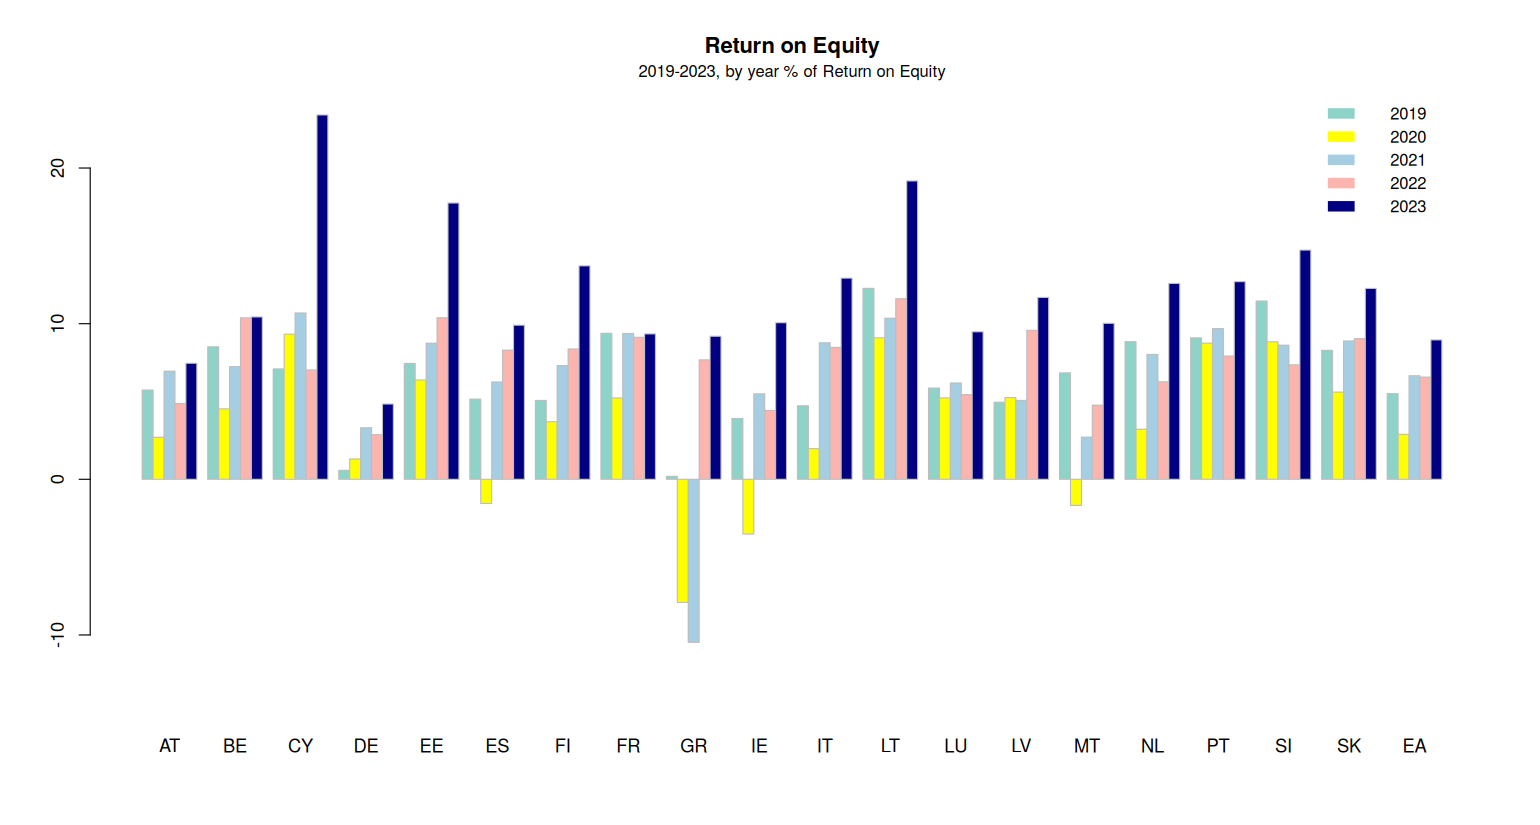

In [14]:
year_bars(year_matrix("roe"), "Return on Equity", "2019-2023, by year % of Return on Equity")

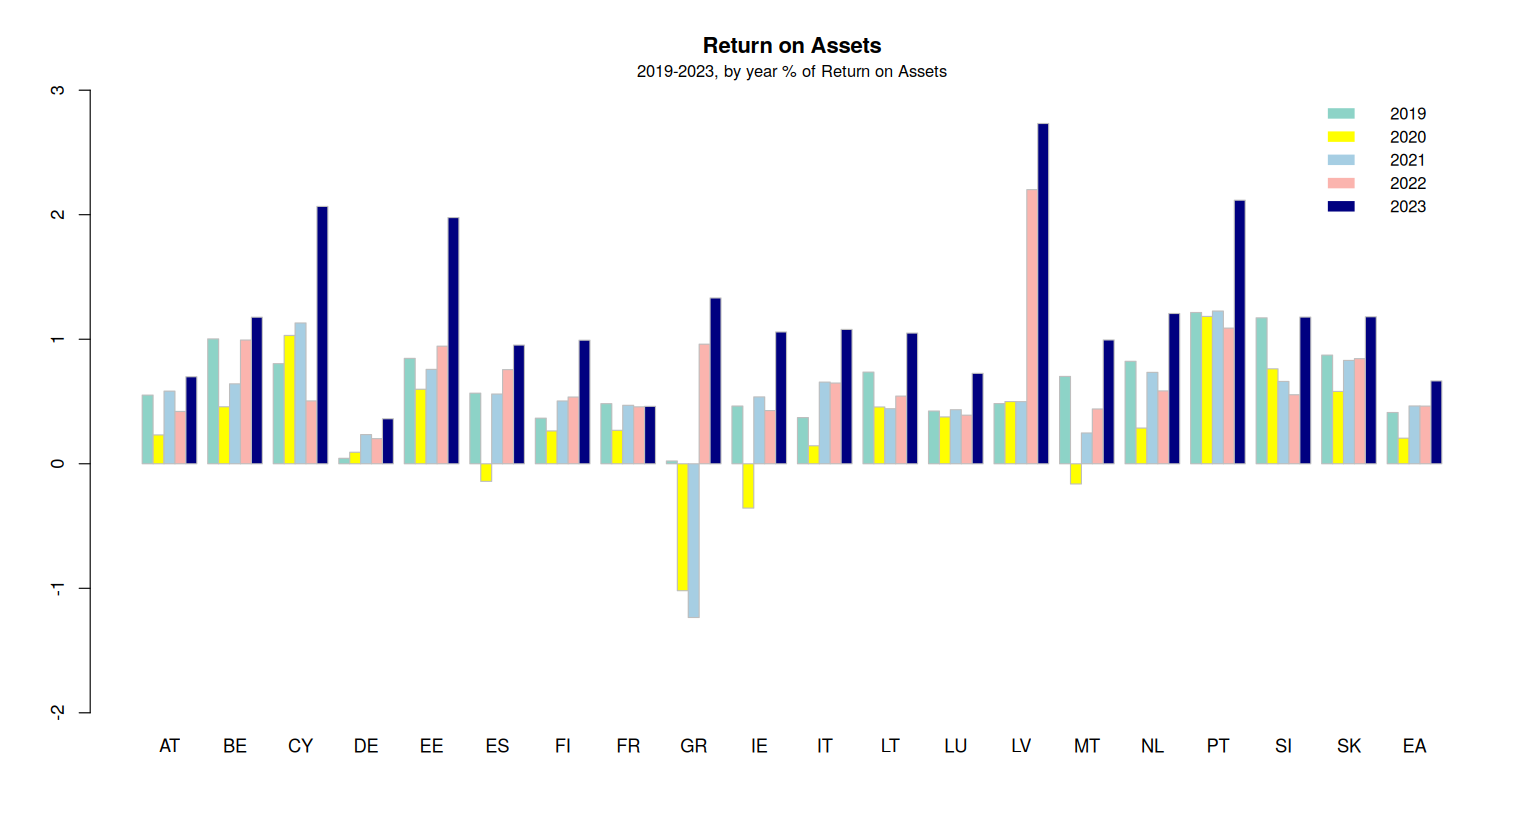

In [15]:
year_bars(year_matrix("roa"), "Return on Assets", "2019-2023, by year % of Return on Assets")

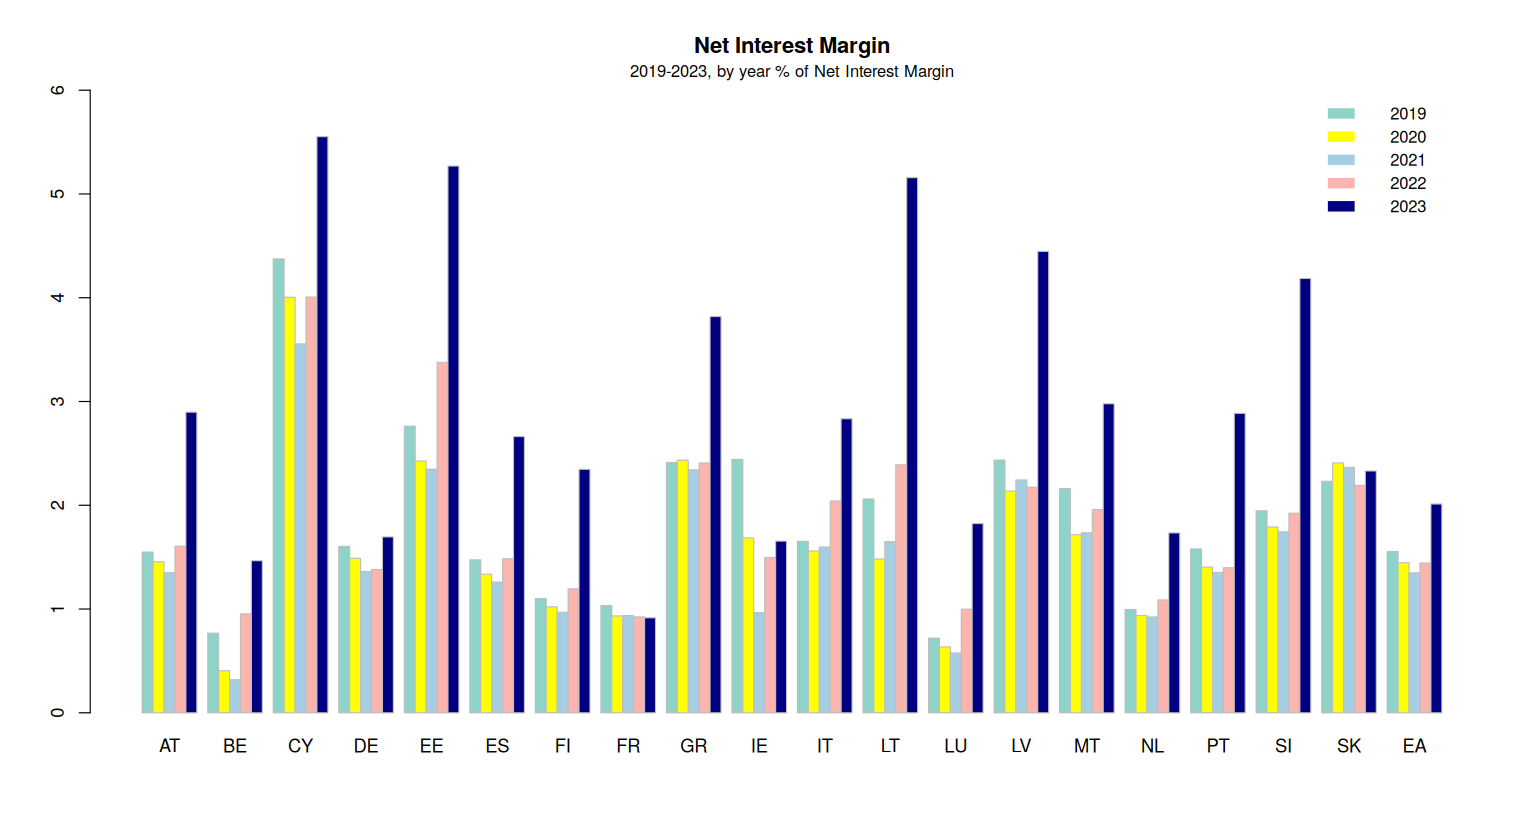

In [16]:
year_bars(year_matrix("nim_median", scale = 1), "Net Interest Margin",
          "2019-2023, by year % of Net Interest Margin")

### Macro-regions

For each region: the distribution of bank-level ROE (median and interquartile range), then the
aggregate NPL ratio and total capital ratio.

#### Northern euro area

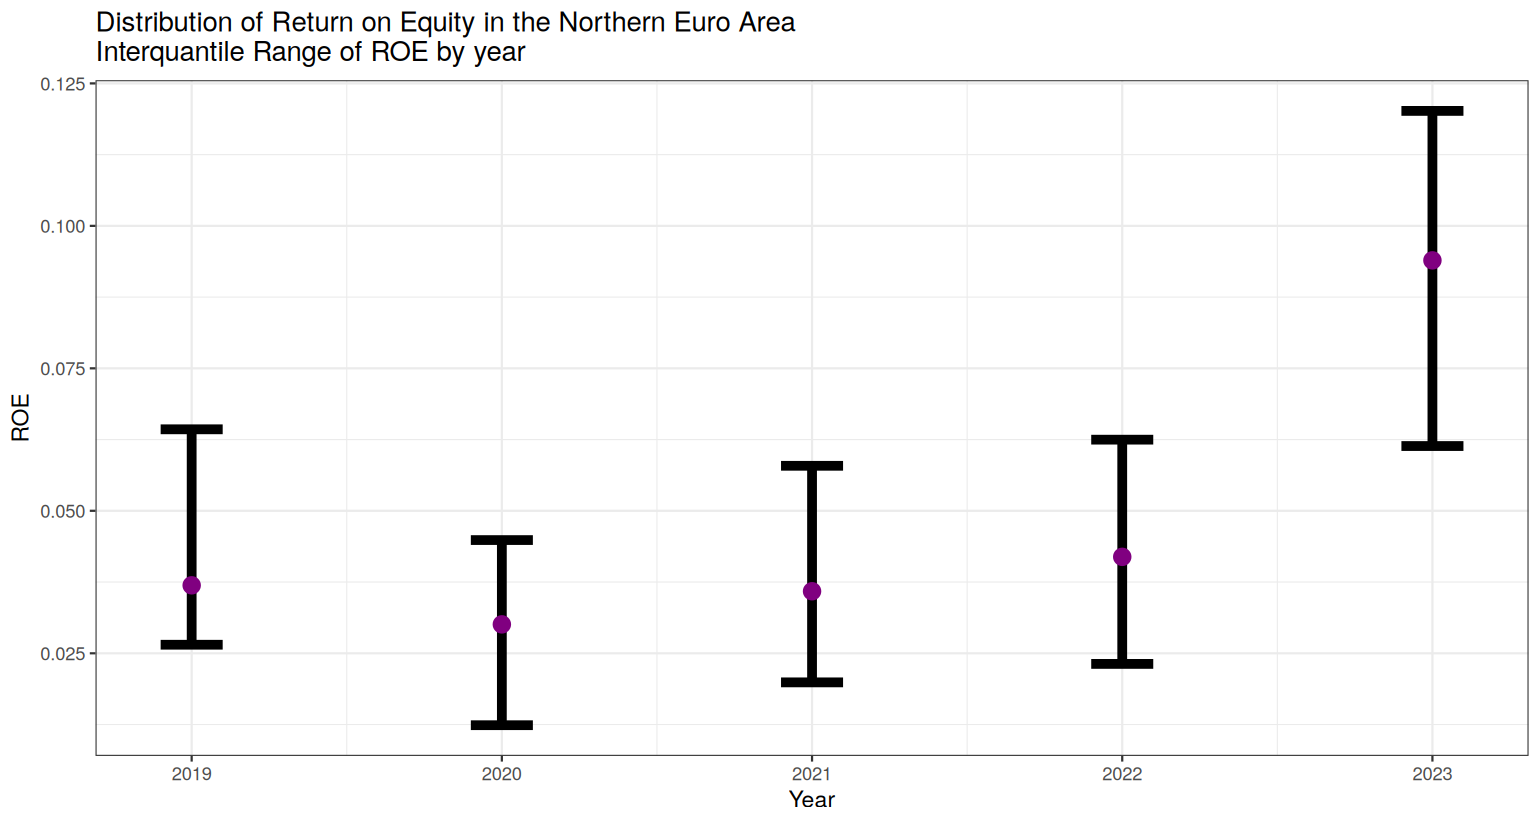

In [17]:
region_roe_chart("North")

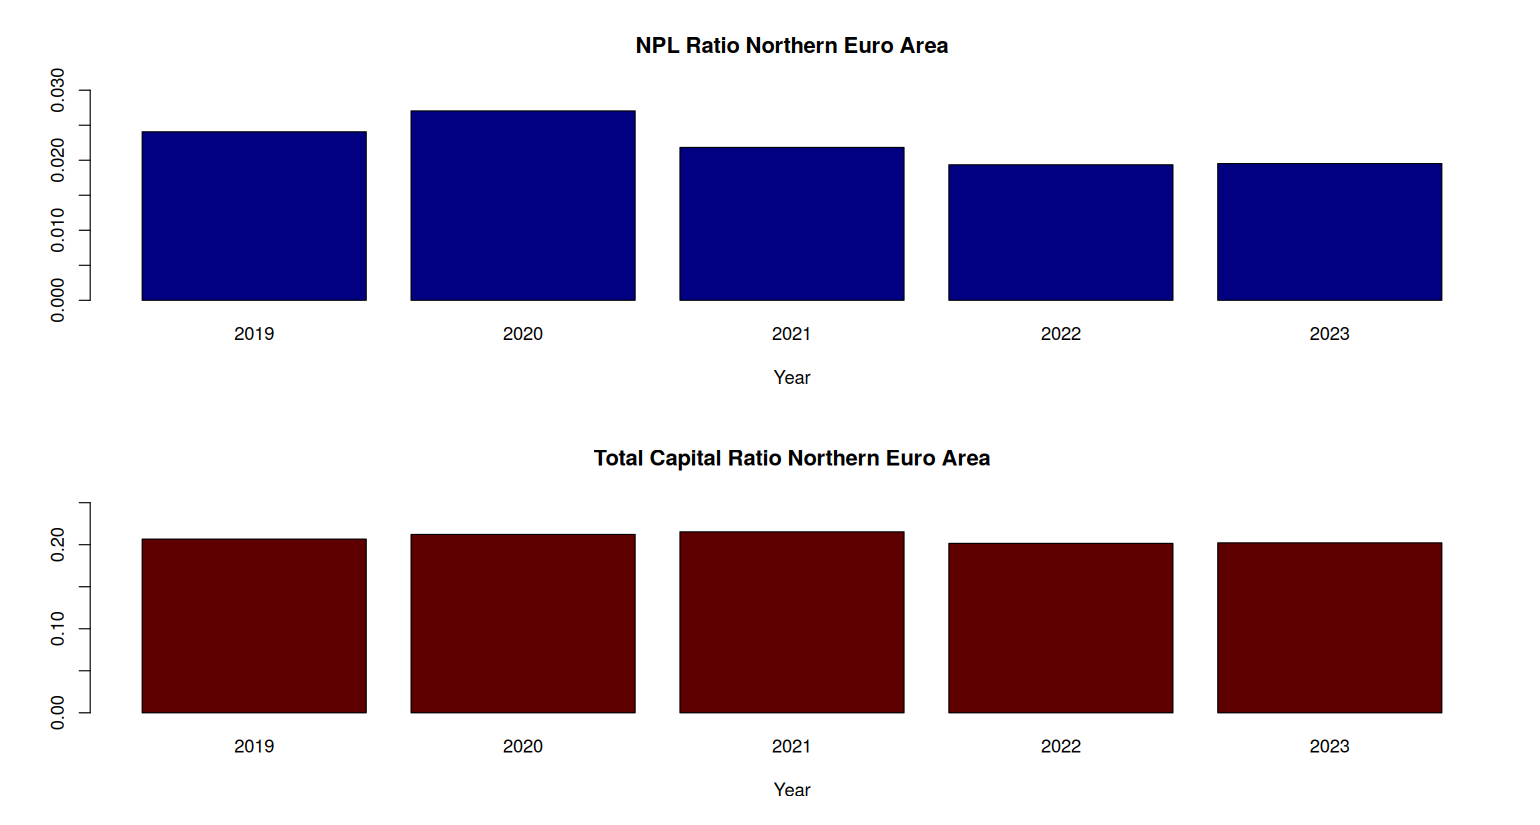

In [18]:
region_npl_capital_chart("North")

#### Eastern euro area

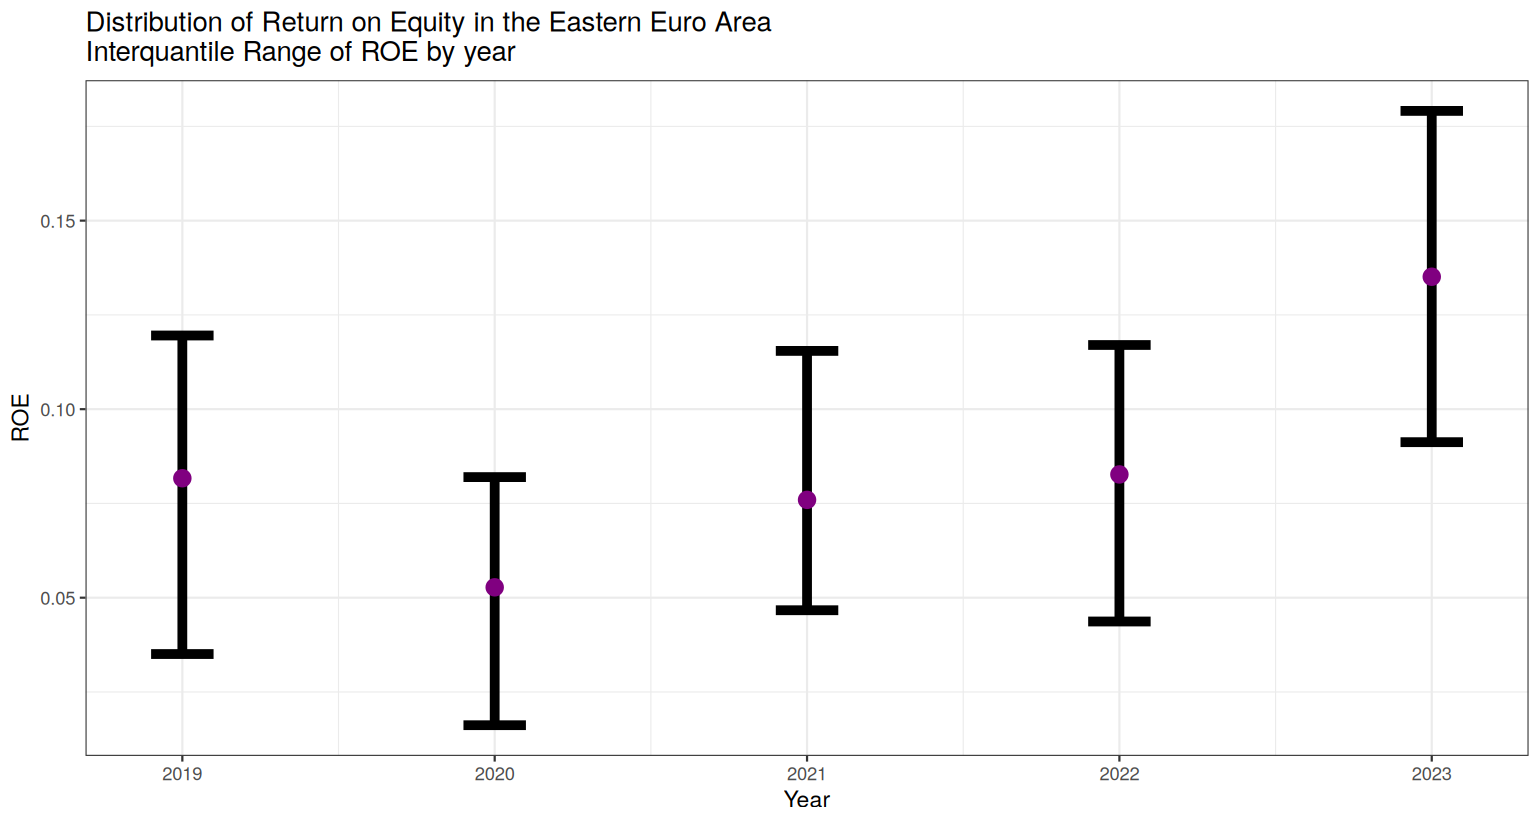

In [19]:
region_roe_chart("East")

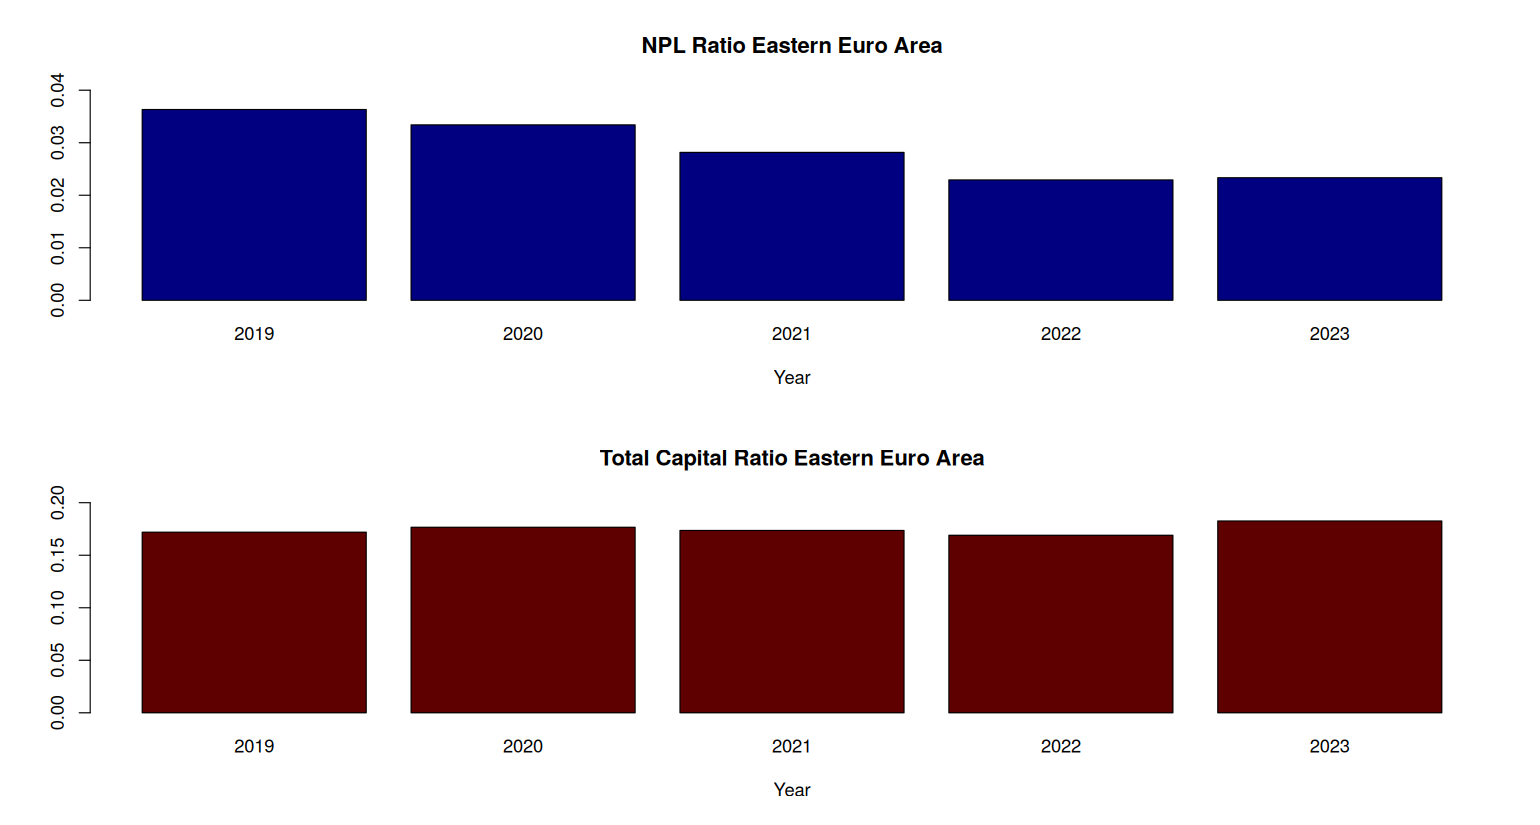

In [20]:
region_npl_capital_chart("East")

#### Southern euro area

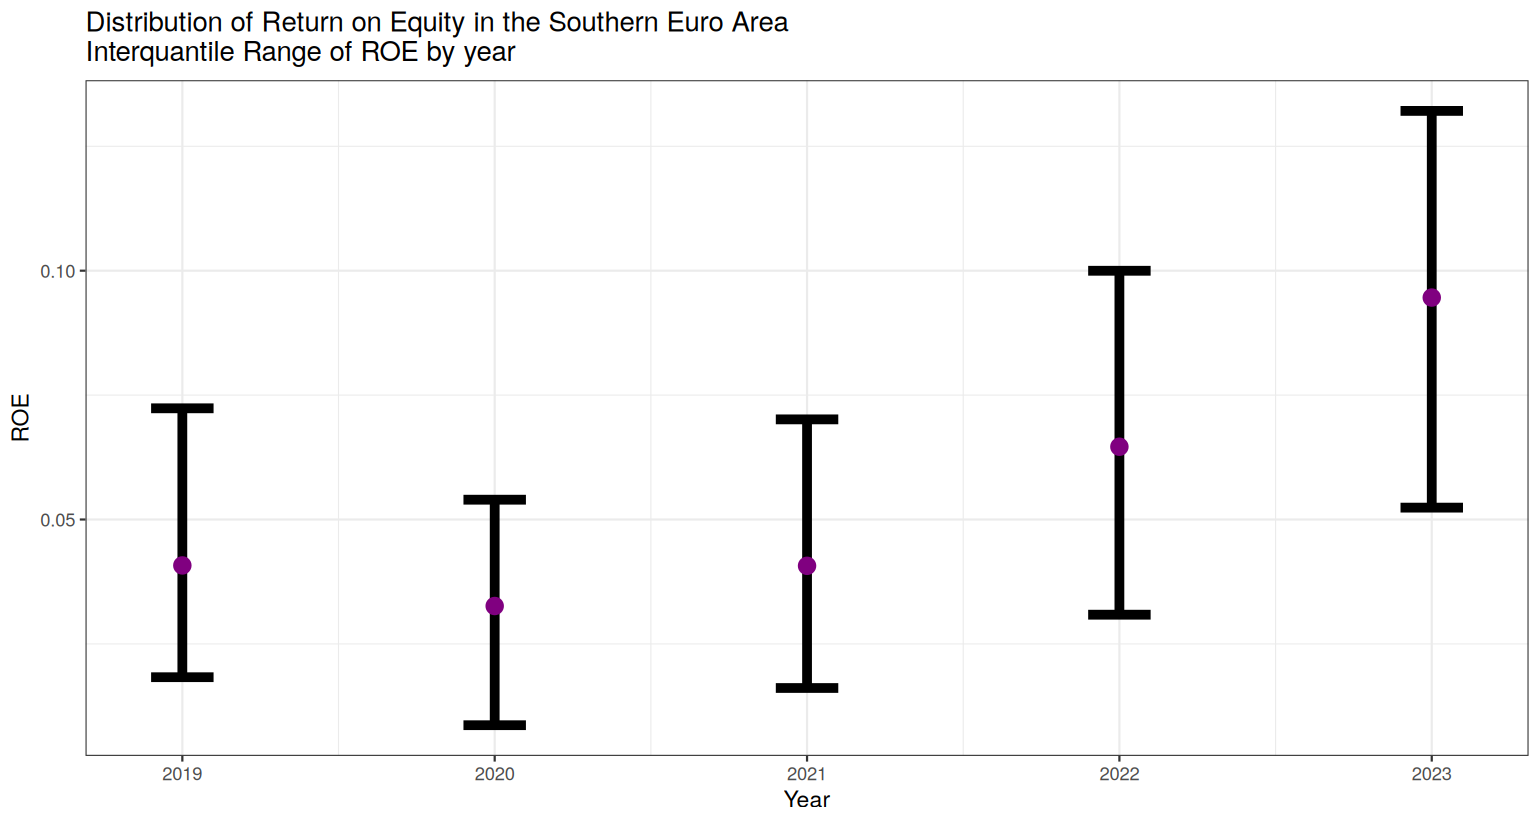

In [21]:
region_roe_chart("South")

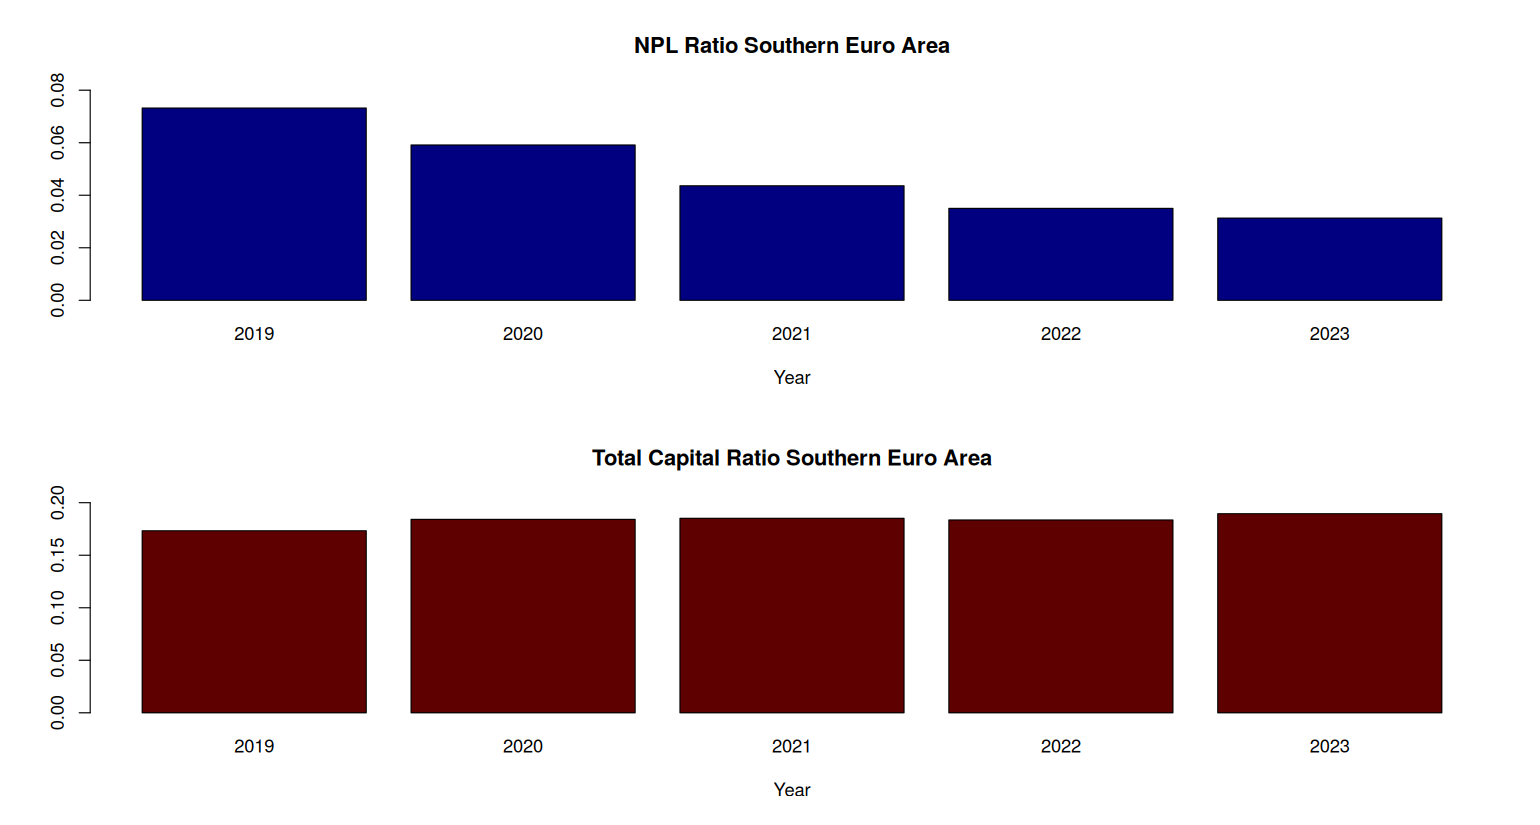

In [22]:
region_npl_capital_chart("South")

#### Central euro area

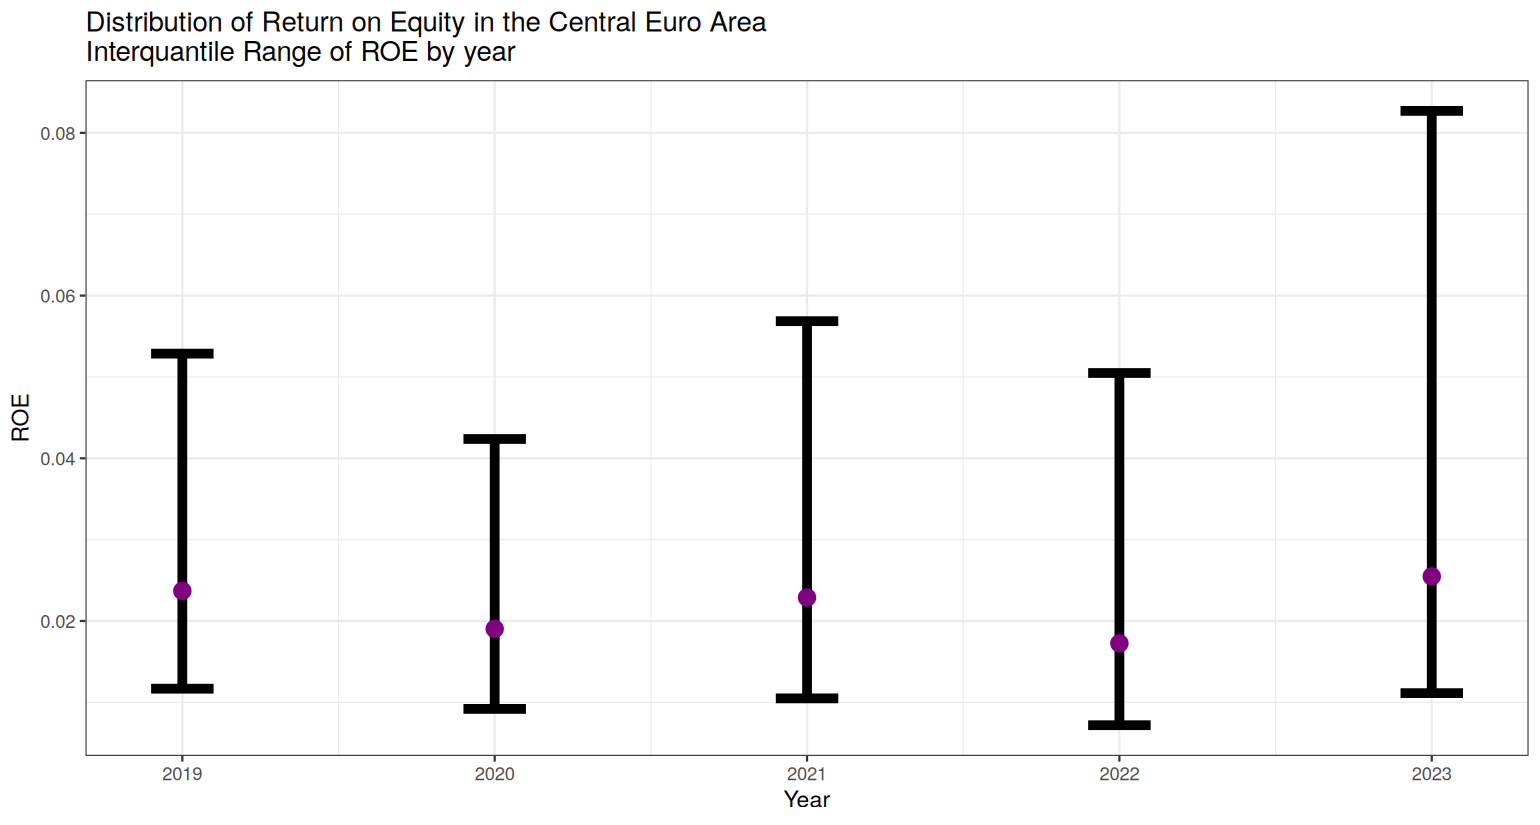

In [23]:
region_roe_chart("Center")

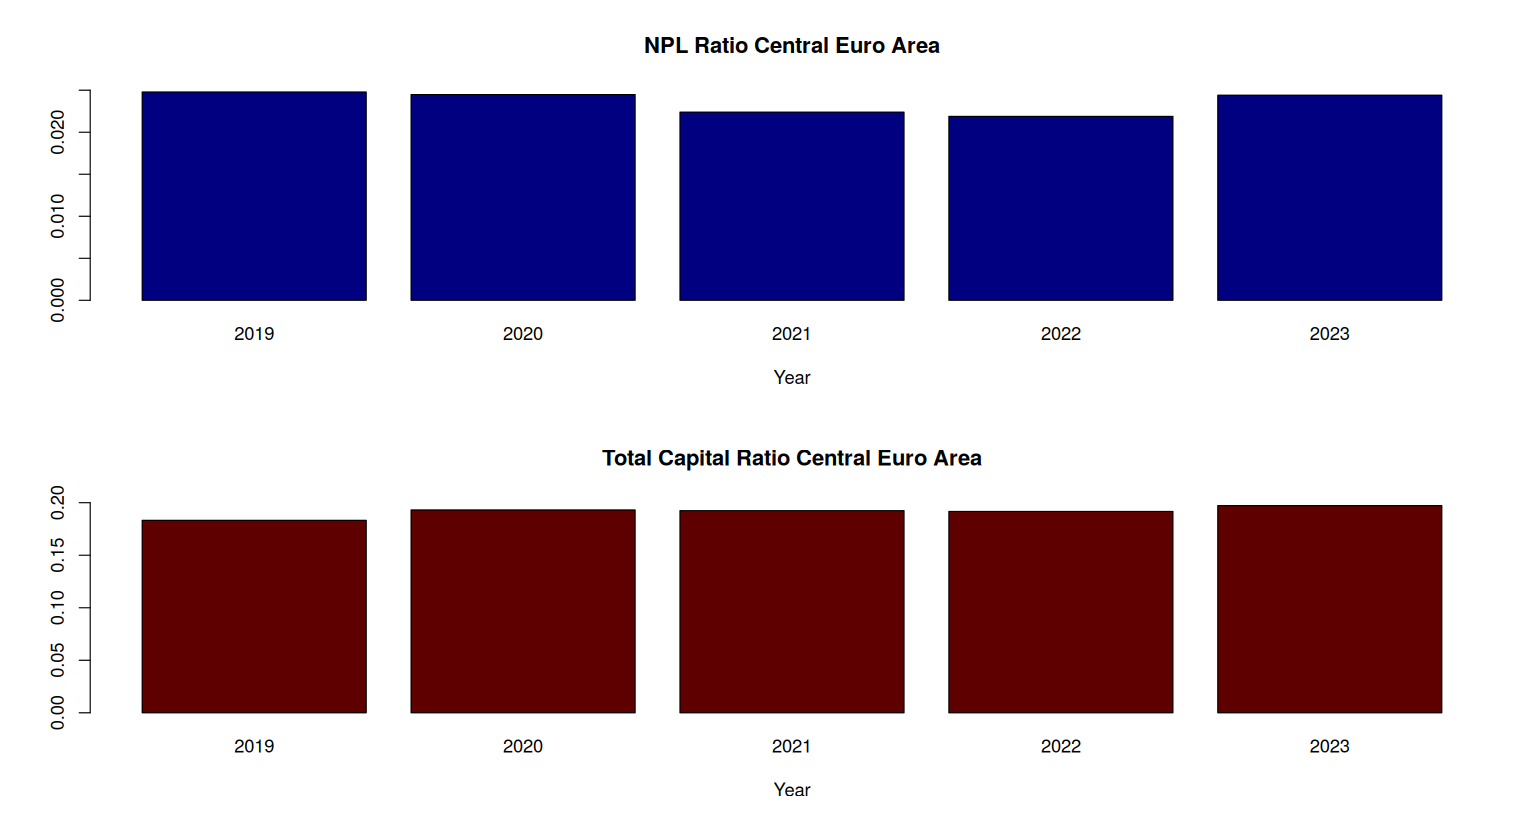

In [24]:
region_npl_capital_chart("Center")

## 5. Saving the results

In [25]:
dir.create(OUT_DIR, showWarnings = FALSE)
# Aggregates only: countries with at least 3 banks, euro area and macro-regions
write.csv(countries, file.path(OUT_DIR, "cs1_country_metrics.csv"), row.names = FALSE)
write.csv(regions,   file.path(OUT_DIR, "cs1_region_metrics.csv"),  row.names = FALSE)
list.files(OUT_DIR)

[1] "cs1_country_metrics.csv" "cs1_region_metrics.csv"